DBSCAN

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn import metrics
from sklearn.neighbors import NearestNeighbors

In [2]:
#Import 2nd Dataset, 2019 Flight Delay Info

delays_2019 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2019_Delay_Data\full_data_flightdelay.csv")

delays_2019.head()

,MONTH,DAY_OF_WEEK,DEP_DEL15,DEP_TIME_BLK,DISTANCE_GROUP,SEGMENT_NUMBER,CONCURRENT_FLIGHTS,NUMBER_OF_SEATS,CARRIER_NAME,AIRPORT_FLIGHTS_MONTH,...,PLANE_AGE,DEPARTING_AIRPORT,LATITUDE,LONGITUDE,PREVIOUS_AIRPORT,PRCP,SNOW,SNWD,TMAX,AWND
0,1,7,0,0800-0859,2,1,25,143,Southwest Airlines Co.,13056,...,8,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
1,1,7,0,0700-0759,7,1,29,191,Delta Air Lines Inc.,13056,...,3,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
2,1,7,0,0600-0659,7,1,27,199,Delta Air Lines Inc.,13056,...,18,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
3,1,7,0,0600-0659,9,1,27,180,Delta Air Lines Inc.,13056,...,2,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91
4,1,7,0,0001-0559,7,1,10,182,Spirit Air Lines,13056,...,1,McCarran International,36.08,-115.152,NONE,0.0,0.0,0.0,65.0,2.91


In [3]:
#The target variable for this dataset is "DEP_DEL15" it is a binary 1 if the flight was delayed more than 15 minutes in its departure delay else 0
delays_2019.drop(["DEP_TIME_BLK","DEPARTING_AIRPORT", "PREVIOUS_AIRPORT", "CARRIER_NAME"], axis=1, inplace=True)

target_2019 = delays_2019["DEP_DEL15"]
variables_2019 = delays_2019.drop(["DEP_DEL15"], axis = 1)

scaled_2019 = StandardScaler().set_output(transform="pandas").fit_transform(variables_2019)

In [4]:
#Sample dataset to reduce runtime of DBSCAN

indexes = np.random.randint(0,len(scaled_2019["MONTH"]),50000)
red_scl_2019 = scaled_2019.iloc[indexes]

In [42]:
#Parameter Tune DBSCAN

best_score = 0
best_eps = 0
best_ms = 0

for eps in [.25,.5,.75,1]:
    for ms in [5,15,25,35,45]:
        db = DBSCAN(eps=eps,min_samples=ms).fit(red_scl_2019)
        labels = db.labels_

        unique_labels = set(labels)
        unique_labels.remove(-1)

        num_clusters = len(unique_labels)

        if num_clusters > 1:
            score = metrics.silhouette_score(red_scl_2019,labels=labels,sample_size=5000,random_state=42)
        
            if score > best_score:
                best_score = score
                best_eps = eps
                best_ms = ms

print(f"The best parameters found were eps = {best_eps:.4f} and ms = {best_ms} for a silhouette score of {best_score:.6f}")

The best parameters found were eps = 0.0000 and ms = 0 for a silhouette score of 0.000000


In [43]:
best_score = 0
best_eps = 0
best_ms = 0

for eps in [2,4,6,8,10]:
    for ms in [5,15,25,35,45]:
        db = DBSCAN(eps=eps,min_samples=ms).fit(red_scl_2019)
        labels = db.labels_

        unique_labels = set(labels)
        unique_labels.remove(-1)

        num_clusters = len(unique_labels)

        if num_clusters > 1:
            score = metrics.silhouette_score(red_scl_2019,labels=labels,sample_size=5000,random_state=42)
        
            if score > best_score:
                best_score = score
                best_eps = eps
                best_ms = ms

print(f"The best parameters found were eps = {best_eps:.4f} and ms = {best_ms} for a silhouette score of {best_score:.6f}")

The best parameters found were eps = 6.0000 and ms = 15 for a silhouette score of 0.719620


In [ ]:
for eps in [5,6,7]:
    for ms in [11,13,15,17,19]:
        db = DBSCAN(eps=eps,min_samples=ms).fit(red_scl_2019)
        labels = db.labels_

        unique_labels = set(labels)
        unique_labels.remove(-1)

        num_clusters = len(unique_labels)

        if num_clusters > 1:
            score = metrics.silhouette_score(red_scl_2019,labels=labels,sample_size=5000,random_state=42)
        
            if score > best_score:
                best_score = score
                best_eps = eps
                best_ms = ms

print(f"The best parameters found were eps = {best_eps:.4f} and ms = {best_ms} for a silhouette score of {best_score:.6f}")

The best parameters found were eps = 6.0000 and ms = 15 for a silhouette score of 0.719620


In [33]:
#Run DBSCAN with optimized parameters on sample
db = DBSCAN(eps=6, min_samples=15).fit(red_scl_2019)
sample_labels = db.labels_

#Get core points from sample
cores = sample_labels != 1

X_clustered = red_scl_2019[cores]
y_clustered = sample_labels[cores]

In [34]:
#Train Nearest Neighbors on core points
nn = NearestNeighbors(n_neighbors=1).fit(X_clustered)
#Predict cluster labels
distances, pred_indices = nn.kneighbors(scaled_2019)

full_labels = y_clustered[pred_indices.flatten()]

In [35]:
variables_2019["Cluster"] = full_labels
print(set(variables_2019["Cluster"]))

{0, -1}


In [36]:
cluster_0 = variables_2019[variables_2019['Cluster']==0]
cluster_n1 = variables_2019[variables_2019['Cluster']==-1]
cluster_0.mean() - cluster_n1.mean()

MONTH                            1.876072e+00
DAY_OF_WEEK                      6.467145e-01
DISTANCE_GROUP                  -4.538634e-01
SEGMENT_NUMBER                   1.987255e-01
CONCURRENT_FLIGHTS               1.372892e+01
NUMBER_OF_SEATS                 -4.879075e+00
AIRPORT_FLIGHTS_MONTH            5.274383e+03
AIRLINE_FLIGHTS_MONTH            1.701869e+04
AIRLINE_AIRPORT_FLIGHTS_MONTH    1.519885e+03
AVG_MONTHLY_PASS_AIRPORT         6.007328e+05
AVG_MONTHLY_PASS_AIRLINE         1.860830e+06
FLT_ATTENDANTS_PER_PASS          1.957173e-05
GROUND_SERV_PER_PASS            -1.281786e-05
PLANE_AGE                       -2.078564e-01
LATITUDE                        -1.245756e+01
LONGITUDE                        1.991155e+01
PRCP                            -1.349999e+00
SNOW                            -3.187638e+00
SNWD                            -8.785471e+00
TMAX                             3.462464e+01
AWND                            -1.270130e+00
Cluster                          1

Text(0.5, 1.0, '2019 Flight Delay Data Cluster Results')

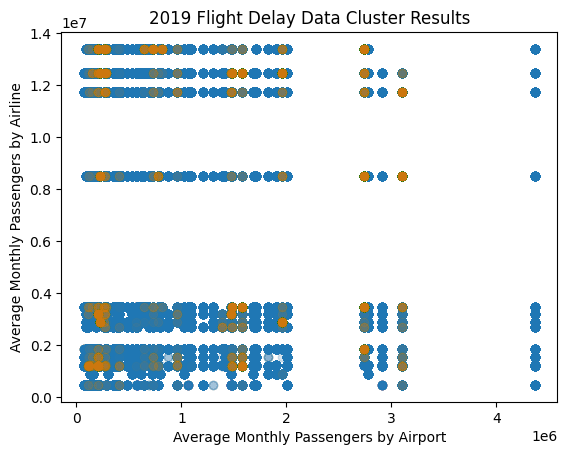

In [37]:
plt.scatter(cluster_0["AVG_MONTHLY_PASS_AIRPORT"], cluster_0["AVG_MONTHLY_PASS_AIRLINE"], alpha=.02)
plt.scatter(cluster_n1["AVG_MONTHLY_PASS_AIRPORT"], cluster_n1["AVG_MONTHLY_PASS_AIRLINE"], alpha=.02)
plt.xlabel("Average Monthly Passengers by Airport")
plt.ylabel("Average Monthly Passengers by Airline")
plt.title("2019 Flight Delay Data Cluster Results")

Text(0.5, 1.0, '2019 Flight Delay Data Cluster Results')

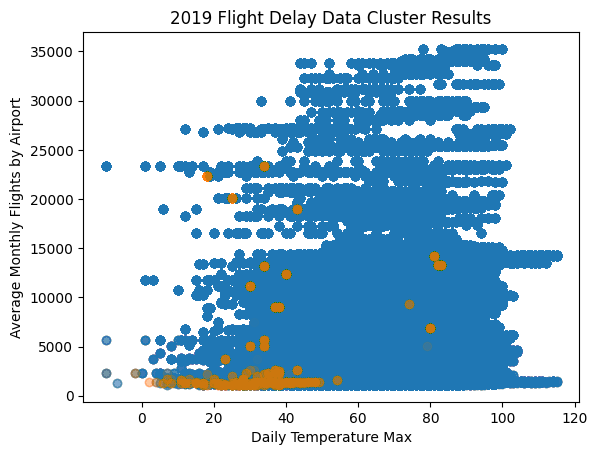

In [38]:
plt.scatter(cluster_0["TMAX"], cluster_0["AIRPORT_FLIGHTS_MONTH"], alpha=.02)
plt.scatter(cluster_n1["TMAX"], cluster_n1["AIRPORT_FLIGHTS_MONTH"], alpha=.02)
plt.xlabel("Daily Temperature Max")
plt.ylabel("Average Monthly Flights by Airport")
plt.title("2019 Flight Delay Data Cluster Results")

C:\Users\lemrd\AppData\Local\Temp\ipykernel_15308\923974188.py:7: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig("2019 Flight Delay Data Modified DBSCAN Cluster Results.png")
C:\Users\lemrd\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


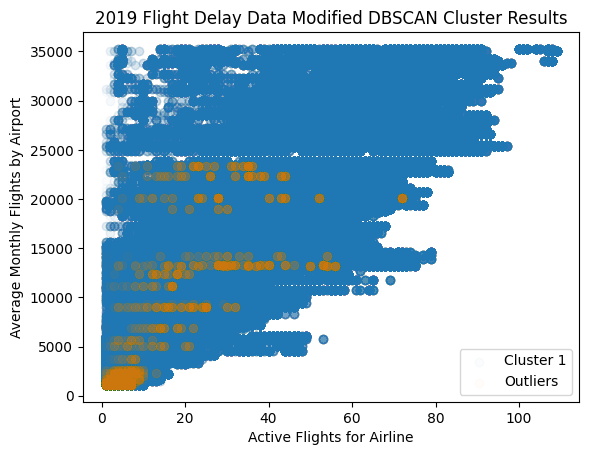

In [39]:
plt.scatter(cluster_0["CONCURRENT_FLIGHTS"], cluster_0["AIRPORT_FLIGHTS_MONTH"], alpha=.02, label="Cluster 1")
plt.scatter(cluster_n1["CONCURRENT_FLIGHTS"], cluster_n1["AIRPORT_FLIGHTS_MONTH"], alpha=.02, label="Outliers")
plt.xlabel("Active Flights for Airline")
plt.ylabel("Average Monthly Flights by Airport")
plt.title("2019 Flight Delay Data Modified DBSCAN Cluster Results")
plt.legend()
plt.savefig("2019 Flight Delay Data Modified DBSCAN Cluster Results.png")

In [5]:
#Import smallest dataset to be appended to other datasets
#This dataset is measure of a few simple totals that work as a representation of the logistical complexity of each airport
domestic_data_2024 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\T100_Domestic_Market_and_Segment_Data_8942359590531559889.csv")
domestic_data_2024.drop(["year", "enplanements", "arrivals", "OBJECTID"], axis=1, inplace=True) #Redundant with other columns
domestic_data_2024.head()

,origin,passengers,departures,freight,mail
0,01A,17,5,0,0
1,05A,1,1,0,0
2,06A,55,67,139,0
3,09A,43,15,0,0
4,1B1,32,7,0,0


In [6]:
#Import 2015 Flight Delay Data
#Columns 7,8 needed dtype specified directly as infer failed

flights_2015 = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\2015_Delay_Data\flights.csv", dtype={"DESTINATION_AIRPORT":str, "ORIGIN_AIRPORT":str})

flights_2015.fillna({"AIR_SYSTEM_DELAY":0,"SECURITY_DELAY":0,"AIRLINE_DELAY":0,"LATE_AIRCRAFT_DELAY":0,"WEATHER_DELAY":0}, inplace=True)
flights_2015.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,408.0,-22.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,741.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,811.0,5.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,756.0,-9.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,259.0,-21.0,0,0,NaN,0.0,0.0,0.0,0.0,0.0


In [7]:
#Append airport logistics numbers to the 2015 Flight Delay Dataset
domestic_data_2024.rename({"origin" : "ORIGIN_AIRPORT"}, inplace=True, axis=1)
flight_2015_extended = pd.merge(flights_2015, domestic_data_2024, how='left', on="ORIGIN_AIRPORT")
flight_2015_extended.head()

,YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,...,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,passengers,departures,freight,mail
0,2015,1,1,4,AS,98,N407AS,ANC,SEA,5,...,NaN,0.0,0.0,0.0,0.0,0.0,2702278.0,71765.0,3.116064e+09,95095127.0
1,2015,1,1,4,AA,2336,N3KUAA,LAX,PBI,10,...,NaN,0.0,0.0,0.0,0.0,0.0,26340206.0,206637.0,8.440161e+08,47992961.0
2,2015,1,1,4,US,840,N171US,SFO,CLT,20,...,NaN,0.0,0.0,0.0,0.0,0.0,17666714.0,138571.0,2.182348e+08,8795256.0
3,2015,1,1,4,AA,258,N3HYAA,LAX,MIA,20,...,NaN,0.0,0.0,0.0,0.0,0.0,26340206.0,206637.0,8.440161e+08,47992961.0
4,2015,1,1,4,AS,135,N527AS,SEA,ANC,25,...,NaN,0.0,0.0,0.0,0.0,0.0,22288303.0,191107.0,3.490318e+08,14452644.0


In [8]:
#Drop Non-Numeric Columns
flight_2015_delay_vars = flight_2015_extended.drop(["AIRLINE", "TAIL_NUMBER", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "CANCELLATION_REASON"], axis=1)
flight_2015_delay_vars.dropna(axis=0, inplace=True)

target = flight_2015_delay_vars["ARRIVAL_DELAY"]
variables = flight_2015_delay_vars.drop("ARRIVAL_DELAY", axis=1)

#Scale features
scaler = StandardScaler().set_output(transform="pandas")
variables_scl = scaler.fit_transform(variables)

In [9]:
#Sample dataset to reduce runtime of DBSCAN

indexes = np.random.randint(0,len(variables_scl["YEAR"]),50000)
red_variables_scl = variables_scl.iloc[indexes]

In [10]:
#Parameter Tune DBSCAN

best_score = 0
best_eps = 0
best_ms = 0

for eps in [.25,.5,.75,1]:
    for ms in [5,15,25,35,45]:
        db = DBSCAN(eps=eps,min_samples=ms).fit(red_variables_scl)
        labels = db.labels_

        unique_labels = set(labels)
        unique_labels.remove(-1)

        num_clusters = len(unique_labels)

        if num_clusters > 1:
            score = metrics.silhouette_score(red_variables_scl,labels=labels,sample_size=5000,random_state=42)
        
            if score > best_score:
                best_score = score
                best_eps = eps
                best_ms = ms

print(f"The best parameters found were eps = {best_eps:.4f} and ms = {best_ms} for a silhouette score of {best_score:.6f}")

The best parameters found were eps = 0.0000 and ms = 0 for a silhouette score of 0.000000


In [13]:
for eps in [2,4,6,8,10]:
    for ms in [5,15,25,35,45]:
        db = DBSCAN(eps=eps,min_samples=ms).fit(red_variables_scl)
        labels = db.labels_

        unique_labels = set(labels)
        unique_labels.remove(-1)

        num_clusters = len(unique_labels)

        if num_clusters > 1:
            score = metrics.silhouette_score(red_variables_scl,labels=labels,sample_size=5000,random_state=42)
        
            if score > best_score:
                best_score = score
                best_eps = eps
                best_ms = ms

print(f"The best parameters found were eps = {best_eps:.4f} and ms = {best_ms} for a silhouette score of {best_score:.6f}")

The best parameters found were eps = 8.0000 and ms = 45 for a silhouette score of 0.658482


In [14]:
for eps in [7.5,8,8.5]:
    for ms in [41,45,49,53,57]:
        db = DBSCAN(eps=eps,min_samples=ms).fit(red_variables_scl)
        labels = db.labels_

        unique_labels = set(labels)
        unique_labels.remove(-1)

        num_clusters = len(unique_labels)

        if num_clusters > 1:
            score = metrics.silhouette_score(red_variables_scl,labels=labels,sample_size=5000,random_state=42)
        
            if score > best_score:
                best_score = score
                best_eps = eps
                best_ms = ms

print(f"The best parameters found were eps = {best_eps:.4f} and ms = {best_ms} for a silhouette score of {best_score:.6f}")

The best parameters found were eps = 7.5000 and ms = 49 for a silhouette score of 0.658538


The Silhouette score has stopped meaningfully improving

In [40]:
#Run DBSCAN with optimized parameters on sample
db = DBSCAN(eps=7.5, min_samples=49).fit(red_variables_scl)
sample_labels = db.labels_

#Get core points from sample
cores = sample_labels != 1

X_clustered = red_variables_scl[cores]
y_clustered = sample_labels[cores]

#Train Nearest Neighbors on core points
nn = NearestNeighbors(n_neighbors=1).fit(X_clustered)

#Predict cluster labels
distances, pred_indices = nn.kneighbors(variables_scl)

full_labels = y_clustered[pred_indices.flatten()]

variables["Cluster"] = full_labels
print(set(variables["Cluster"]))

{0, -1}


In [56]:
cluster_0 = variables[variables['Cluster']==0]
cluster_n1 = variables[variables['Cluster']==-1]
cluster_0.mean() - cluster_n1.mean()

YEAR                   0.000000e+00
MONTH                  2.430374e-02
DAY                   -2.123512e-01
DAY_OF_WEEK            4.075016e-02
FLIGHT_NUMBER         -1.737067e+02
SCHEDULED_DEPARTURE    2.823085e+01
DEPARTURE_TIME        -2.980879e+01
DEPARTURE_DELAY       -1.491435e+02
TAXI_OUT              -3.765991e+00
WHEELS_OFF            -2.076134e+01
SCHEDULED_TIME         8.086431e+00
ELAPSED_TIME          -1.828962e+00
AIR_TIME               8.302775e+00
DISTANCE               1.045489e+02
WHEELS_ON              8.731859e+01
TAXI_IN               -6.365746e+00
SCHEDULED_ARRIVAL      3.334995e+01
ARRIVAL_TIME           9.709328e+01
DIVERTED               0.000000e+00
CANCELLED              0.000000e+00
AIR_SYSTEM_DELAY      -2.922852e+01
SECURITY_DELAY        -3.663501e+00
AIRLINE_DELAY         -6.174922e+01
LATE_AIRCRAFT_DELAY   -2.367946e+01
WEATHER_DELAY         -3.829782e+01
passengers             8.136553e+06
departures             4.186100e+04
freight               -1.297

Text(0.5, 1.0, '2015 Flight Delay Data Cluster Results')

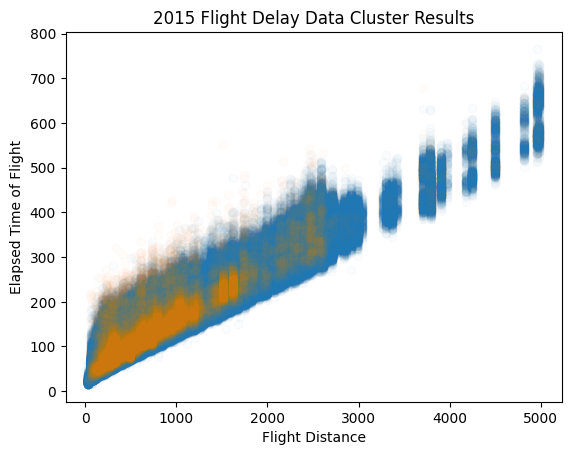

In [44]:
plt.scatter(cluster_0["DISTANCE"], cluster_0["ELAPSED_TIME"], alpha=.02)
plt.scatter(cluster_n1["DISTANCE"], cluster_n1["ELAPSED_TIME"], alpha=.02)
plt.xlabel("Flight Distance")
plt.ylabel("Elapsed Time of Flight")
plt.title("2015 Flight Delay Data Cluster Results")

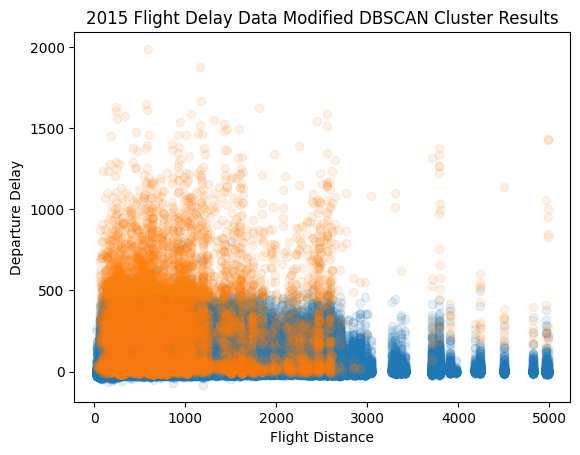

In [58]:
plt.scatter(cluster_0["DISTANCE"], cluster_0["DEPARTURE_DELAY"], alpha=.10)
plt.scatter(cluster_n1["DISTANCE"], cluster_n1["DEPARTURE_DELAY"], alpha=.10)
plt.xlabel("Flight Distance")
plt.ylabel("Departure Delay")
plt.title("2015 Flight Delay Data Modified DBSCAN Cluster Results")
plt.savefig("2015 Flight Delay Data Modified DBSCAN Cluster Results.png")

In [10]:
#Import Delays and Causes Dataset

delay_causes = pd.read_csv(r"C:\Users\lemrd\Downloads\OMDS\Mod B\Sem 2\Data\Flight_Delay_and_Causes_Data\Flight_delay.csv")
#Remove the few duplicate datapoints
delay_causes.drop_duplicates(keep="first", inplace=True)
#Drop columns with no information (all values are the same)
delay_causes.drop(["Cancelled","Diverted","CancellationCode"],axis=1, inplace=True)
#Fix long delays to break out of 24 hour time to show the real delay length
data_to_shift = delay_causes[delay_causes["ArrTime"] < (delay_causes["CRSArrTime"] - 100)].index
delay_causes.loc[data_to_shift,"ArrTime"] = delay_causes.loc[data_to_shift,"ArrTime"] + 2400
                           
delay_causes.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,Dest,Dest_Airport,Distance,TaxiIn,TaxiOut,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,BWI,Baltimore-Washington International Airport,515,3,10,2,0,0,0,32
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,LAS,McCarran International Airport,1591,3,7,10,0,0,0,47
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,MCO,Orlando International Airport,828,6,8,8,0,0,0,72
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,PHX,Phoenix Sky Harbor International Airport,1489,7,8,3,0,0,0,12
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,TPA,Tampa International Airport,838,4,9,0,0,0,0,16


In [11]:
#Append Logistics Dataset
domestic_data_2024.rename({"ORIGIN_AIRPORT" : "Origin"}, inplace=True, axis=1)
delay_causes_extended = pd.merge(delay_causes, domestic_data_2024, how='left', on="Origin")
delay_causes_extended.head()

,DayOfWeek,Date,DepTime,ArrTime,CRSArrTime,UniqueCarrier,Airline,FlightNum,TailNum,ActualElapsedTime,...,TaxiOut,CarrierDelay,WeatherDelay,NASDelay,SecurityDelay,LateAircraftDelay,passengers,departures,freight,mail
0,4,03-01-2019,1829,1959,1925,WN,Southwest Airlines Co.,3920,N464WN,90,...,10,2,0,0,0,32,5194000.0,60772.0,842478043.0,84741.0
1,4,03-01-2019,1937,2037,1940,WN,Southwest Airlines Co.,509,N763SW,240,...,7,10,0,0,0,47,5194000.0,60772.0,842478043.0,84741.0
2,4,03-01-2019,1644,1845,1725,WN,Southwest Airlines Co.,1333,N334SW,121,...,8,8,0,0,0,72,5194000.0,60772.0,842478043.0,84741.0
3,4,03-01-2019,1452,1640,1625,WN,Southwest Airlines Co.,675,N286WN,228,...,8,3,0,0,0,12,5194000.0,60772.0,842478043.0,84741.0
4,4,03-01-2019,1323,1526,1510,WN,Southwest Airlines Co.,4,N674AA,123,...,9,0,0,0,0,16,5194000.0,60772.0,842478043.0,84741.0


In [12]:
#Drop non-numeric columns
num_delay_causes = delay_causes_extended.drop(["Date", "UniqueCarrier", "Airline", "TailNum", "Origin", "Org_Airport", "Dest", "Dest_Airport"], axis = 1)
#Drop missing data
num_delay_causes.dropna(axis=0, inplace=True)

target_delay = num_delay_causes["ArrDelay"]
variables_delay = num_delay_causes.drop(["ArrDelay"], axis = 1)

#Scale Data
scaler = StandardScaler().set_output(transform="pandas")
variables_scl_delay = scaler.fit_transform(variables_delay)

In [13]:
#Sample dataset to reduce runtime of DBSCAN

indexes = np.random.randint(0,len(variables_scl_delay["ArrTime"]),50000)
red_variables_scl_delay = variables_scl_delay.iloc[indexes]

In [21]:
#Parameter Tune DBSCAN

best_score = 0
best_eps = 0
best_ms = 0

for eps in [.25,.5,.75,1]:
    for ms in [5,15,25,35,45]:
        db = DBSCAN(eps=eps,min_samples=ms).fit(red_variables_scl_delay)
        labels = db.labels_

        unique_labels = set(labels)
        unique_labels.remove(-1)

        num_clusters = len(unique_labels)

        if num_clusters > 1:
            score = metrics.silhouette_score(red_variables_scl_delay,labels=labels,sample_size=5000,random_state=42)
        
            if score > best_score:
                best_score = score
                best_eps = eps
                best_ms = ms

print(f"The best parameters found were eps = {best_eps:.4f} and ms = {best_ms} for a silhouette score of {best_score:.6f}")

The best parameters found were eps = 0.0000 and ms = 0 for a silhouette score of 0.000000


In [22]:
for eps in [2,4,6,8,10]:
    for ms in [5,15,25,35,45]:
        db = DBSCAN(eps=eps,min_samples=ms).fit(red_variables_scl_delay)
        labels = db.labels_

        unique_labels = set(labels)
        unique_labels.remove(-1)

        num_clusters = len(unique_labels)

        if num_clusters > 1:
            score = metrics.silhouette_score(red_variables_scl_delay,labels=labels,sample_size=5000,random_state=42)
        
            if score > best_score:
                best_score = score
                best_eps = eps
                best_ms = ms

print(f"The best parameters found were eps = {best_eps:.4f} and ms = {best_ms} for a silhouette score of {best_score:.6f}")

The best parameters found were eps = 8.0000 and ms = 45 for a silhouette score of 0.645463


In [14]:
#Running Next day so reinitializing best params
best_score = 0.645463
best_eps = 8
best_ms = 45

for eps in [7.5,8,8.5]:
    for ms in [41,45,49,53,57]:
        db = DBSCAN(eps=eps,min_samples=ms).fit(red_variables_scl_delay)
        labels = db.labels_

        unique_labels = set(labels)
        unique_labels.remove(-1)

        num_clusters = len(unique_labels)

        if num_clusters > 1:
            score = metrics.silhouette_score(red_variables_scl_delay,labels=labels,sample_size=5000,random_state=42)
        
            if score > best_score:
                best_score = score
                best_eps = eps
                best_ms = ms

print(f"The best parameters found were eps = {best_eps:.4f} and ms = {best_ms} for a silhouette score of {best_score:.6f}")

The best parameters found were eps = 7.5000 and ms = 49 for a silhouette score of 0.649758


The Silhouette score has stopped meaningfully increasing

In [48]:
#Run DBSCAN with optimized parameters on sample
db = DBSCAN(eps=7.5, min_samples=49).fit(red_variables_scl_delay)
sample_labels = db.labels_

#Get core points from sample
cores = sample_labels != 1

X_clustered = red_variables_scl_delay[cores]
y_clustered = sample_labels[cores]

#Train Nearest Neighbors on core points
nn = NearestNeighbors(n_neighbors=1).fit(X_clustered)

#Predict cluster labels
distances, pred_indices = nn.kneighbors(variables_scl_delay)

full_labels = y_clustered[pred_indices.flatten()]

variables_delay["Cluster"] = full_labels
print(set(variables_delay["Cluster"]))

{0, -1}


In [49]:
cluster_0 = variables_delay[variables_delay['Cluster']==0]
cluster_n1 = variables_delay[variables_delay['Cluster']==-1]
cluster_0.mean() - cluster_n1.mean()

DayOfWeek           -1.507333e-01
DepTime              1.234998e+02
ArrTime             -3.175301e+02
CRSArrTime           1.194454e+02
FlightNum           -7.421339e+02
ActualElapsedTime   -1.443583e+01
CRSElapsedTime       1.756494e+00
AirTime              2.713726e+00
DepDelay            -2.502987e+02
Distance             2.508567e+01
TaxiIn              -7.419721e+00
TaxiOut             -9.729837e+00
CarrierDelay        -1.379626e+02
WeatherDelay        -4.334932e+01
NASDelay            -3.892127e+01
SecurityDelay       -2.252247e+01
LateAircraftDelay   -2.373533e+01
passengers           9.233388e+06
departures           6.451388e+04
freight             -7.498095e+08
mail                -9.085918e+07
Cluster              1.000000e+00
dtype: float64

Text(0.5, 1.0, 'Flight Delay and Causes Data Cluster Results')

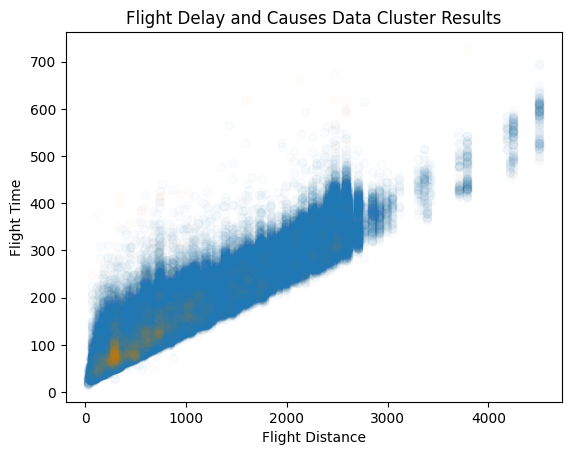

In [50]:
plt.scatter(cluster_0["Distance"], cluster_0["ActualElapsedTime"], alpha=.02)
plt.scatter(cluster_n1["Distance"], cluster_n1["ActualElapsedTime"], alpha=.02)
plt.xlabel("Flight Distance")
plt.ylabel("Flight Time")
plt.title("Flight Delay and Causes Data Cluster Results")

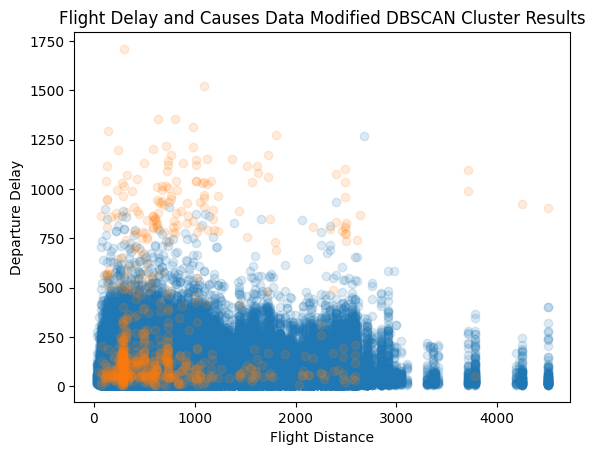

In [54]:
plt.scatter(cluster_0["Distance"], cluster_0["DepDelay"], alpha=.15)
plt.scatter(cluster_n1["Distance"], cluster_n1["DepDelay"], alpha=.15)
plt.xlabel("Flight Distance")
plt.ylabel("Departure Delay")
plt.title("Flight Delay and Causes Data Modified DBSCAN Cluster Results")
plt.savefig("Flight Delay and Causes Data Modified DBSCAN Cluster Results.png")